In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Install timm

In [1]:
!pip install -q timm

Import Libraries

In [2]:
import gc
import random
import shutil
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("EfficientNet-B2 Cell 2 imports completed.")

EfficientNet-B2 Cell 2 imports completed.


Configuration and Reproducibility

In [3]:
MODEL_NAME = "efficientnet_b2"

SEED = 42
IMAGE_SIZE = 260
BATCH_SIZE = 16
NUM_WORKERS = 2

TOTAL_EPOCHS = 50
HEAD_EPOCHS = 5

HEAD_LR = 1e-3
BACKBONE_LR = 1e-5
FINETUNE_HEAD_LR = 1e-4
WEIGHT_DECAY = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"

MODEL_DIR = Path(
    "/kaggle/working/efficientnet_b2"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Model:", MODEL_NAME)
print("Device:", DEVICE)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Total epochs:", TOTAL_EPOCHS)
print("Output directory:", MODEL_DIR)

Model: efficientnet_b2
Device: cuda
Image size: 260
Batch size: 16
Total epochs: 50
Output directory: /kaggle/working/efficientnet_b2


Load Metadata and Match Image Paths

In [4]:
INPUT_DIR = Path("/kaggle/input")


metadata_files = list(
    INPUT_DIR.rglob("HAM10000_metadata.csv")
)

if not metadata_files:
    raise FileNotFoundError(
        "HAM10000_metadata.csv was not found. "
        "Add the HAM10000 dataset to this notebook."
    )

metadata_path = metadata_files[0]
dataset_dir = metadata_path.parent

print("Metadata path:", metadata_path)
print("Dataset directory:", dataset_dir)


df = pd.read_csv(metadata_path)


image_paths = {}

for extension in ("*.jpg", "*.jpeg", "*.png"):
    for image_path in dataset_dir.rglob(extension):
        image_paths[image_path.stem] = str(image_path)


df["path"] = df["image_id"].map(image_paths)

matched_images = df["path"].notna().sum()
missing_images = df["path"].isna().sum()

print("Metadata rows:", len(df))
print("Matched images:", matched_images)
print("Missing images:", missing_images)


df = df.dropna(subset=["path"]).reset_index(drop=True)

if len(df) == 0:
    raise RuntimeError(
        "No HAM10000 images were matched with the metadata."
    )

print("Final usable samples:", len(df))
df.head()

Metadata path: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
Dataset directory: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
Metadata rows: 10015
Matched images: 10015
Missing images: 0
Final usable samples: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...


Create Class Labels

In [5]:
class_names = sorted(df["dx"].unique().tolist())

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}

df["label"] = df["dx"].map(class_to_idx).astype(int)

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("Class mapping:")

for class_name, class_index in class_to_idx.items():
    print(f"{class_name}: {class_index}")

print("\nClass distribution:")
print(df["dx"].value_counts())

Number of classes: 7
Class mapping:
akiec: 0
bcc: 1
bkl: 2
df: 3
mel: 4
nv: 5
vasc: 6

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


Lesion-Level Train, Validation, and Test Split

In [6]:

first_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=SEED
)

train_indices, temporary_indices = next(
    first_split.split(
        df,
        groups=df["lesion_id"]
    )
)

train_df = df.iloc[train_indices].reset_index(drop=True)
temporary_df = df.iloc[temporary_indices].reset_index(drop=True)


second_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=SEED
)

validation_indices, test_indices = next(
    second_split.split(
        temporary_df,
        groups=temporary_df["lesion_id"]
    )
)

validation_df = temporary_df.iloc[
    validation_indices
].reset_index(drop=True)

test_df = temporary_df.iloc[
    test_indices
].reset_index(drop=True)


train_lesions = set(train_df["lesion_id"])
validation_lesions = set(validation_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

assert train_lesions.isdisjoint(validation_lesions)
assert train_lesions.isdisjoint(test_lesions)
assert validation_lesions.isdisjoint(test_lesions)

print("Total samples:", len(df))
print("Training samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Test samples:", len(test_df))

print("\nUnique lesions")
print("Training lesions:", train_df["lesion_id"].nunique())
print("Validation lesions:", validation_df["lesion_id"].nunique())
print("Test lesions:", test_df["lesion_id"].nunique())

print("\nTraining class distribution:")
print(train_df["dx"].value_counts().sort_index())

print("\nValidation class distribution:")
print(validation_df["dx"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df["dx"].value_counts().sort_index())

print("\nNo lesion overlap was found.")

Total samples: 10015
Training samples: 7002
Validation samples: 1519
Test samples: 1494

Unique lesions
Training lesions: 5229
Validation lesions: 1120
Test lesions: 1121

Training class distribution:
dx
akiec     207
bcc       381
bkl       741
df         89
mel       770
nv       4718
vasc       96
Name: count, dtype: int64

Validation class distribution:
dx
akiec     57
bcc       65
bkl      206
df        19
mel      156
nv       991
vasc      25
Name: count, dtype: int64

Test class distribution:
dx
akiec     63
bcc       68
bkl      152
df         7
mel      187
nv       996
vasc      21
Name: count, dtype: int64

No lesion overlap was found.


Image Transformations and Augmentation

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            IMAGE_SIZE,
            scale=(0.80, 1.00)
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(
            brightness=0.20,
            contrast=0.20,
            saturation=0.20,
            hue=0.05
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        )
    ]
)

validation_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        )
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        )
    ]
)

print("Training, validation, and test transformations created.")
print("Input image size:", IMAGE_SIZE)

Training, validation, and test transformations created.
Input image size: 260


Create the Dataset Class

In [8]:
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = Image.open(row["path"]).convert("RGB")
        label = int(row["label"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label


train_dataset = HAM10000Dataset(
    dataframe=train_df,
    transform=train_transform
)

validation_dataset = HAM10000Dataset(
    dataframe=validation_df,
    transform=validation_transform
)

test_dataset = HAM10000Dataset(
    dataframe=test_df,
    transform=test_transform
)

print("Training dataset size:", len(train_dataset))
print("Validation dataset size:", len(validation_dataset))
print("Test dataset size:", len(test_dataset))

sample_image, sample_label = train_dataset[0]

print("Sample image shape:", sample_image.shape)
print("Sample label:", sample_label)
print("Sample class:", idx_to_class[sample_label])

Training dataset size: 7002
Validation dataset size: 1519
Test dataset size: 1494
Sample image shape: torch.Size([3, 260, 260])
Sample label: 2
Sample class: bkl


Data Loaders, Class Weights, and Loss Function

In [9]:
loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    persistent_workers=NUM_WORKERS > 0,
    generator=loader_generator
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    persistent_workers=NUM_WORKERS > 0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    persistent_workers=NUM_WORKERS > 0
)


class_counts = (
    train_df["label"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

if (class_counts == 0).any():
    missing_class_indices = class_counts[class_counts == 0].index.tolist()

    raise ValueError(
        f"Training split contains no samples for classes: "
        f"{missing_class_indices}"
    )

class_weights = np.sqrt(
    len(train_df) /
    (NUM_CLASSES * class_counts.values)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)


train_df.to_csv(
    MODEL_DIR / "train_split.csv",
    index=False
)

validation_df.to_csv(
    MODEL_DIR / "validation_split.csv",
    index=False
)

test_df.to_csv(
    MODEL_DIR / "test_split.csv",
    index=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

print("\nTraining class counts:")
print(class_counts)

print("\nClass weights:")

for class_index, weight in enumerate(class_weights.detach().cpu().numpy()):
    print(f"{idx_to_class[class_index]}: {weight:.4f}")

print("\nLoss function:", criterion)
print("Data splits saved successfully.")

Training batches: 438
Validation batches: 95
Test batches: 94

Training class counts:
label
0     207
1     381
2     741
3      89
4     770
5    4718
6      96
Name: count, dtype: int64

Class weights:
akiec: 2.1982
bcc: 1.6203
bkl: 1.1619
df: 3.3525
mel: 1.1398
nv: 0.4605
vasc: 3.2279

Loss function: CrossEntropyLoss()
Data splits saved successfully.


Create the Pretrained Model

In [10]:
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(DEVICE)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Model created successfully.")
print("Model name:", MODEL_NAME)
print("Number of classes:", NUM_CLASSES)
print("Device:", DEVICE)
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print("\nClassifier:")
print(model.get_classifier())

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Model created successfully.
Model name: efficientnet_b2
Number of classes: 7
Device: cuda
Total parameters: 7,710,857
Trainable parameters: 7,710,857

Classifier:
Linear(in_features=1408, out_features=7, bias=True)


Freeze Backbone and Prepare Head Training

In [11]:

for parameter in model.parameters():
    parameter.requires_grad = False


classifier = model.get_classifier()

for parameter in classifier.parameters():
    parameter.requires_grad = True


optimizer = torch.optim.AdamW(
    classifier.parameters(),
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=HEAD_EPOCHS
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

frozen_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if not parameter.requires_grad
)

print("Backbone frozen successfully.")
print("Only the classifier is trainable.")
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Frozen parameters: {frozen_parameters:,}")
print("Optimizer:", optimizer.__class__.__name__)
print("Initial learning rate:", optimizer.param_groups[0]["lr"])
print("AMP enabled:", USE_AMP)

Backbone frozen successfully.
Only the classifier is trainable.
Trainable parameters: 9,863
Frozen parameters: 7,700,994
Optimizer: AdamW
Initial learning rate: 0.001
AMP enabled: True


Training and Evaluation Functions

In [12]:
from tqdm.auto import tqdm


def train_one_epoch(
    model,
    data_loader,
    optimizer,
    criterion,
    scaler
):
    model.train()

    running_loss = 0.0
    all_targets = []
    all_predictions = []

    progress_bar = tqdm(
        data_loader,
        desc="Training",
        leave=False
    )

    for images, targets in progress_bar:
        images = images.to(
            DEVICE,
            non_blocking=True
        )

        targets = targets.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        ):
            outputs = model(images)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        predictions = outputs.argmax(dim=1)

        running_loss += (
            loss.item() * images.size(0)
        )

        all_targets.extend(
            targets.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = (
        running_loss / len(data_loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    epoch_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_f1
    )


@torch.no_grad()
def evaluate_model(
    model,
    data_loader,
    criterion
):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_predictions = []
    all_probabilities = []

    progress_bar = tqdm(
        data_loader,
        desc="Evaluating",
        leave=False
    )

    for images, targets in progress_bar:
        images = images.to(
            DEVICE,
            non_blocking=True
        )

        targets = targets.to(
            DEVICE,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        ):
            outputs = model(images)
            loss = criterion(outputs, targets)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = probabilities.argmax(
            dim=1
        )

        running_loss += (
            loss.item() * images.size(0)
        )

        all_targets.extend(
            targets.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.detach().cpu().numpy()
        )

    evaluation_loss = (
        running_loss / len(data_loader.dataset)
    )

    evaluation_accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    evaluation_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return {
        "loss": evaluation_loss,
        "accuracy": evaluation_accuracy,
        "f1": evaluation_f1,
        "targets": np.asarray(all_targets),
        "predictions": np.asarray(all_predictions),
        "probabilities": np.asarray(all_probabilities)
    }


print("Training and evaluation functions created successfully.")

Training and evaluation functions created successfully.


50-Epoch Training, Fine-Tuning, Checkpointing, and Auto-Resume

In [13]:
BEST_MODEL_PATH = MODEL_DIR / "efficientnet_b2_best_model.pth"
LAST_CHECKPOINT_PATH = MODEL_DIR / "efficientnet_b2_last_checkpoint.pth"
HISTORY_PATH = MODEL_DIR / "training_history.csv"


def setup_head_training():
    for parameter in model.parameters():
        parameter.requires_grad = False

    classifier = model.get_classifier()

    for parameter in classifier.parameters():
        parameter.requires_grad = True

    new_optimizer = torch.optim.AdamW(
        classifier.parameters(),
        lr=HEAD_LR,
        weight_decay=WEIGHT_DECAY
    )

    new_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        new_optimizer,
        T_max=HEAD_EPOCHS
    )

    return new_optimizer, new_scheduler


def setup_fine_tuning():
    for parameter in model.parameters():
        parameter.requires_grad = True

    classifier = model.get_classifier()

    classifier_parameter_ids = {
        id(parameter)
        for parameter in classifier.parameters()
    }

    backbone_parameters = [
        parameter
        for parameter in model.parameters()
        if id(parameter) not in classifier_parameter_ids
    ]

    new_optimizer = torch.optim.AdamW(
        [
            {
                "params": backbone_parameters,
                "lr": BACKBONE_LR
            },
            {
                "params": classifier.parameters(),
                "lr": FINETUNE_HEAD_LR
            }
        ],
        weight_decay=WEIGHT_DECAY
    )

    new_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        new_optimizer,
        T_max=TOTAL_EPOCHS - HEAD_EPOCHS
    )

    return new_optimizer, new_scheduler


history = {
    "epoch": [],
    "phase": [],
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": [],
    "backbone_lr": [],
    "head_lr": []
}

start_epoch = 1
best_val_f1 = -1.0
current_phase = "head"

optimizer, scheduler = setup_head_training()


if LAST_CHECKPOINT_PATH.exists():
    print("Checkpoint found. Resuming training...")

    try:
        checkpoint = torch.load(
            LAST_CHECKPOINT_PATH,
            map_location=DEVICE,
            weights_only=False
        )
    except TypeError:
        checkpoint = torch.load(
            LAST_CHECKPOINT_PATH,
            map_location=DEVICE
        )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    completed_epoch = checkpoint["epoch"]
    start_epoch = completed_epoch + 1

    best_val_f1 = checkpoint.get(
        "best_val_f1",
        -1.0
    )

    history = checkpoint.get(
        "history",
        history
    )

    saved_phase = checkpoint.get(
        "phase",
        "head" if completed_epoch <= HEAD_EPOCHS else "fine_tuning"
    )

    current_phase = (
        "head"
        if start_epoch <= HEAD_EPOCHS
        else "fine_tuning"
    )

    if current_phase == "head":
        optimizer, scheduler = setup_head_training()
    else:
        optimizer, scheduler = setup_fine_tuning()

    if saved_phase == current_phase:
        try:
            optimizer.load_state_dict(
                checkpoint["optimizer_state_dict"]
            )

            scheduler.load_state_dict(
                checkpoint["scheduler_state_dict"]
            )

            print("Optimizer and scheduler states restored.")

        except Exception as error:
            print(
                "Optimizer or scheduler state could not be restored:",
                error
            )

    if "scaler_state_dict" in checkpoint:
        try:
            scaler.load_state_dict(
                checkpoint["scaler_state_dict"]
            )
        except Exception:
            pass

    print("Resume epoch:", start_epoch)
    print("Best validation Macro F1:", best_val_f1)

else:
    print("Starting a new EfficientNet-B2 training session.")


if start_epoch > TOTAL_EPOCHS:
    print("Training has already completed 50 epochs.")

else:
    for epoch in range(start_epoch, TOTAL_EPOCHS + 1):

        required_phase = (
            "head"
            if epoch <= HEAD_EPOCHS
            else "fine_tuning"
        )

        if required_phase != current_phase:
            print("\nUnfreezing the complete model...")

            optimizer, scheduler = setup_fine_tuning()
            current_phase = "fine_tuning"

            print("Full fine-tuning started.")

        print("\n" + "=" * 70)
        print(
            f"Epoch {epoch}/{TOTAL_EPOCHS} | "
            f"Phase: {current_phase}"
        )
        print("=" * 70)

        train_loss, train_accuracy, train_f1 = train_one_epoch(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            scaler=scaler
        )

        validation_results = evaluate_model(
            model=model,
            data_loader=validation_loader,
            criterion=criterion
        )

        if current_phase == "head":
            backbone_lr = 0.0
            head_lr = optimizer.param_groups[0]["lr"]
        else:
            backbone_lr = optimizer.param_groups[0]["lr"]
            head_lr = optimizer.param_groups[1]["lr"]

        history["epoch"].append(epoch)
        history["phase"].append(current_phase)
        history["train_loss"].append(float(train_loss))
        history["train_accuracy"].append(float(train_accuracy))
        history["train_f1"].append(float(train_f1))
        history["val_loss"].append(
            float(validation_results["loss"])
        )
        history["val_accuracy"].append(
            float(validation_results["accuracy"])
        )
        history["val_f1"].append(
            float(validation_results["f1"])
        )
        history["backbone_lr"].append(float(backbone_lr))
        history["head_lr"].append(float(head_lr))

        pd.DataFrame(history).to_csv(
            HISTORY_PATH,
            index=False
        )

        if validation_results["f1"] > best_val_f1:
            best_val_f1 = validation_results["f1"]

            torch.save(
                model.state_dict(),
                BEST_MODEL_PATH
            )

            print(
                f"New best model saved. "
                f"Validation Macro F1: {best_val_f1:.4f}"
            )

        scheduler.step()

        checkpoint = {
            "epoch": epoch,
            "phase": current_phase,
            "model_name": MODEL_NAME,
            "num_classes": NUM_CLASSES,
            "class_names": class_names,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_val_f1": best_val_f1,
            "history": history
        }

        torch.save(
            checkpoint,
            LAST_CHECKPOINT_PATH
        )

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Train Macro F1: {train_f1:.4f}"
        )

        print(
            f"Validation Loss: {validation_results['loss']:.4f} | "
            f"Validation Accuracy: {validation_results['accuracy']:.4f} | "
            f"Validation Macro F1: {validation_results['f1']:.4f}"
        )

        print(f"Checkpoint saved after epoch {epoch}")

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("\nEfficientNet-B2 training completed.")
    print("Best validation Macro F1:", best_val_f1)
    print("Best model path:", BEST_MODEL_PATH)
    print("Last checkpoint path:", LAST_CHECKPOINT_PATH)

Starting a new EfficientNet-B2 training session.

Epoch 1/50 | Phase: head


Training:   0%|          | 0/438 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/95 [00:00<?, ?it/s]

New best model saved. Validation Macro F1: 0.2357
Train Loss: 2.9756 | Train Accuracy: 0.4200 | Train Macro F1: 0.2083
Validation Loss: 2.5926 | Validation Accuracy: 0.4510 | Validation Macro F1: 0.2357
Checkpoint saved after epoch 1

Epoch 2/50 | Phase: head


Training:   0%|          | 0/438 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/95 [00:00<?, ?it/s]

Train Loss: 1.1753 | Train Accuracy: 0.9192 | Train Macro F1: 0.8863
Validation Loss: 1.6131 | Validation Accuracy: 0.8032 | Validation Macro F1: 0.6676
Checkpoint saved after epoch 49

Epoch 50/50 | Phase: fine_tuning


Training:   0%|          | 0/438 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/95 [00:00<?, ?it/s]

New best model saved. Validation Macro F1: 0.6716
Train Loss: 1.1770 | Train Accuracy: 0.9097 | Train Macro F1: 0.8802
Validation Loss: 1.6139 | Validation Accuracy: 0.8045 | Validation Macro F1: 0.6716
Checkpoint saved after epoch 50

EfficientNet-B2 training completed.
Best validation Macro F1: 0.6715883630218489
Best model path: /kaggle/working/efficientnet_b2/efficientnet_b2_best_model.pth
Last checkpoint path: /kaggle/working/efficientnet_b2/efficientnet_b2_last_checkpoint.pth


Evaluate the Best Model on the Test Set

In [14]:

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Best model was not found at: {BEST_MODEL_PATH}"
    )

try:
    best_state_dict = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE,
        weights_only=True
    )
except TypeError:
    best_state_dict = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )

model.load_state_dict(best_state_dict)
model = model.to(DEVICE)

print("Best EfficientNet-B2 model loaded successfully.")


test_results = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion
)

test_targets = test_results["targets"]
test_predictions = test_results["predictions"]
test_probabilities = test_results["probabilities"]


test_accuracy = accuracy_score(
    test_targets,
    test_predictions
)

macro_precision = precision_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    test_targets,
    test_predictions,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    test_targets,
    test_predictions,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    test_targets,
    test_predictions,
    average="weighted",
    zero_division=0
)


try:
    macro_roc_auc = roc_auc_score(
        test_targets,
        test_probabilities,
        labels=list(range(NUM_CLASSES)),
        multi_class="ovr",
        average="macro"
    )
except ValueError as error:
    macro_roc_auc = np.nan
    print("ROC-AUC could not be calculated:", error)

test_metrics = {
    "model": MODEL_NAME,
    "test_loss": float(test_results["loss"]),
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "weighted_precision": float(weighted_precision),
    "weighted_recall": float(weighted_recall),
    "weighted_f1": float(weighted_f1),
    "macro_roc_auc_ovr": (
        None
        if np.isnan(macro_roc_auc)
        else float(macro_roc_auc)
    )
}


pd.DataFrame([test_metrics]).to_csv(
    MODEL_DIR / "test_metrics.csv",
    index=False
)

with open(
    MODEL_DIR / "test_metrics.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        test_metrics,
        file,
        indent=4
    )


report_text = classification_report(
    test_targets,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    digits=4,
    zero_division=0
)

report_dict = classification_report(
    test_targets,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

pd.DataFrame(report_dict).transpose().to_csv(
    MODEL_DIR / "classification_report.csv"
)

with open(
    MODEL_DIR / "classification_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(report_text)


prediction_df = test_df[
    ["image_id", "lesion_id", "dx", "label", "path"]
].copy()

prediction_df["true_label"] = test_targets

prediction_df["true_class"] = [
    idx_to_class[int(label)]
    for label in test_targets
]

prediction_df["predicted_label"] = test_predictions

prediction_df["predicted_class"] = [
    idx_to_class[int(label)]
    for label in test_predictions
]

prediction_df["confidence"] = test_probabilities.max(axis=1)

prediction_df["correct_prediction"] = (
    test_targets == test_predictions
)

for class_index, class_name in enumerate(class_names):
    prediction_df[f"probability_{class_name}"] = (
        test_probabilities[:, class_index]
    )

prediction_df.to_csv(
    MODEL_DIR / "test_predictions.csv",
    index=False
)

print("\nTest Results")
print("=" * 60)

for metric_name, metric_value in test_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

print("\nClassification Report")
print("=" * 60)
print(report_text)

print("Test metrics, reports, and predictions saved successfully.")

Best EfficientNet-B2 model loaded successfully.


Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

ROC-AUC could not be calculated: Target scores need to be probabilities for multiclass roc_auc, i.e. they should sum up to 1.0 over classes

Test Results
model: efficientnet_b2
test_loss: 1.6089
test_accuracy: 0.8052
macro_precision: 0.5956
macro_recall: 0.6638
macro_f1: 0.6152
weighted_precision: 0.8082
weighted_recall: 0.8052
weighted_f1: 0.8050
macro_roc_auc_ovr: None

Classification Report
              precision    recall  f1-score   support

       akiec     0.5068    0.5873    0.5441        63
         bcc     0.6389    0.6765    0.6571        68
         bkl     0.7059    0.5526    0.6199       152
          df     0.2222    0.5714    0.3200         7
         mel     0.5562    0.5294    0.5425       187
          nv     0.9096    0.9197    0.9146       996
        vasc     0.6296    0.8095    0.7083        21

    accuracy                         0.8052      1494
   macro avg     0.5956    0.6638    0.6152      1494
weighted avg     0.8082    0.8052    0.8050      1494

Test m

Training Curves and Confusion Matrices

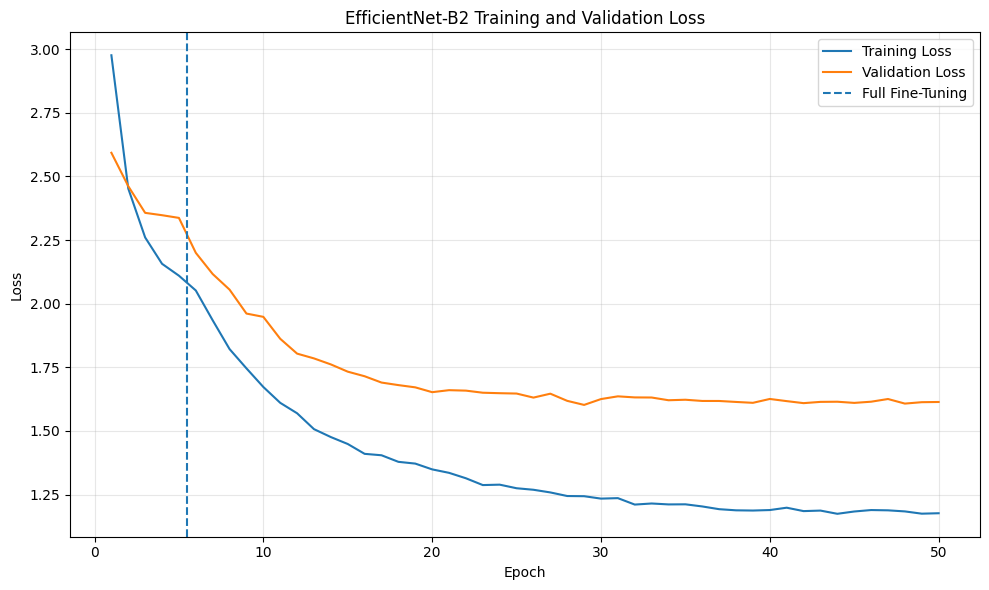

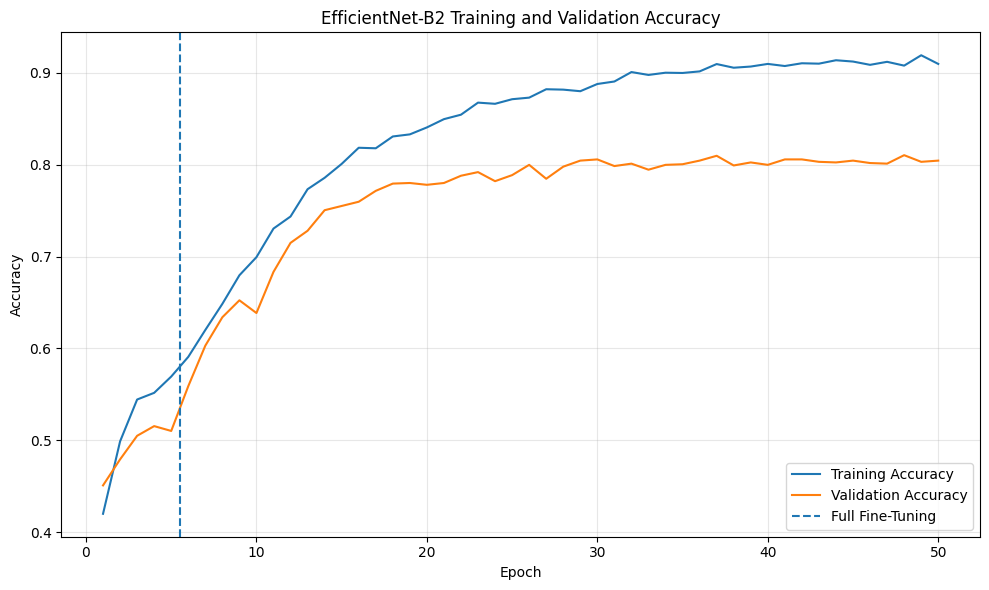

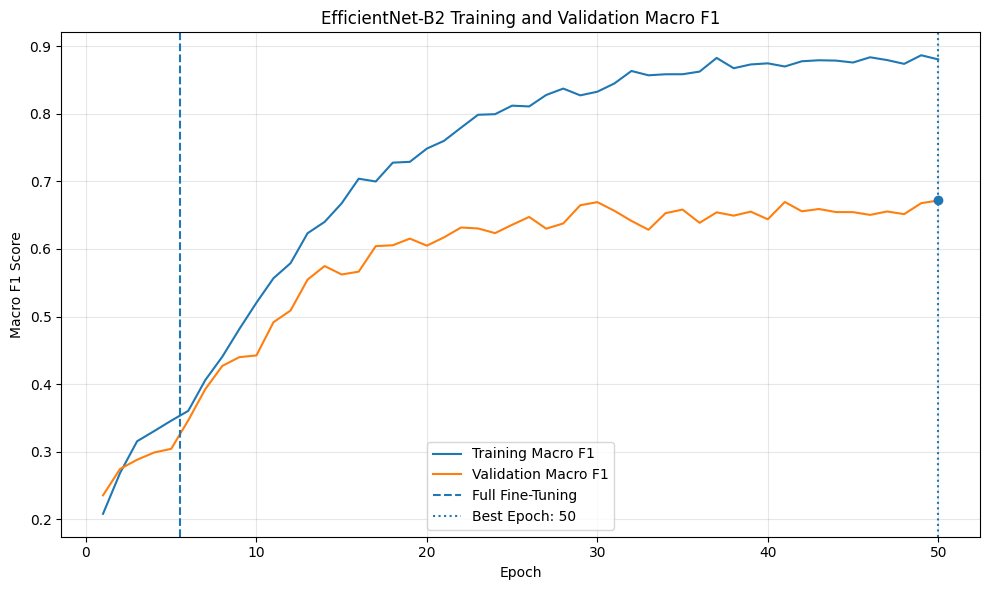

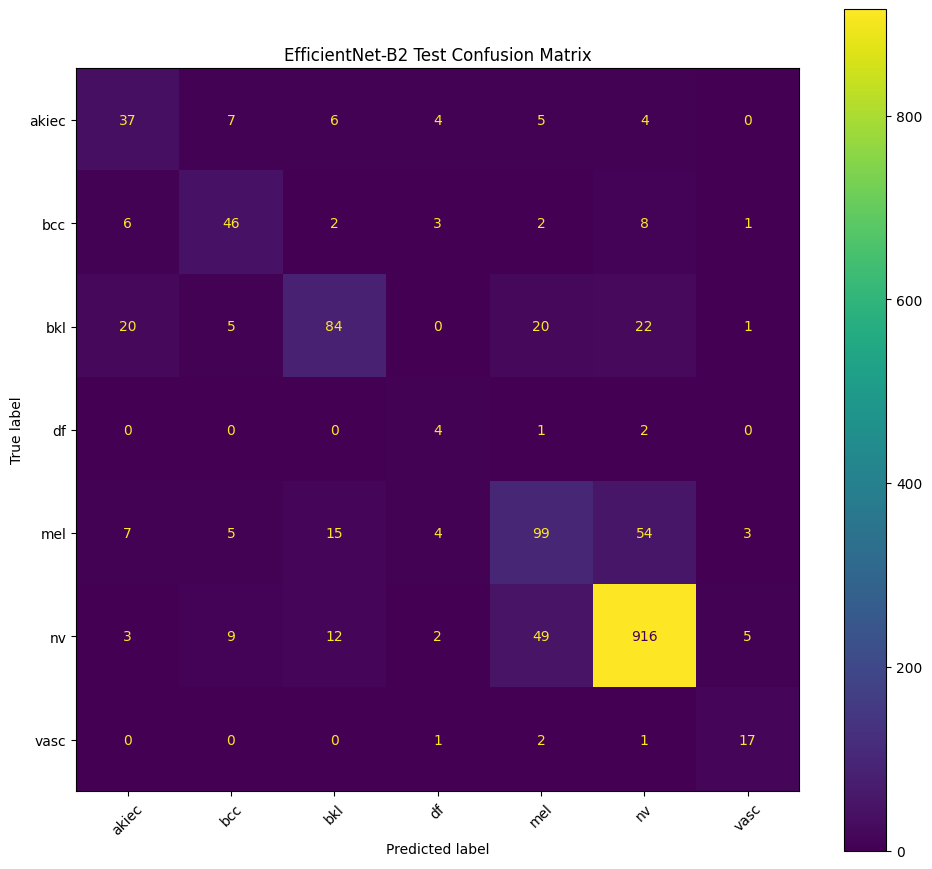

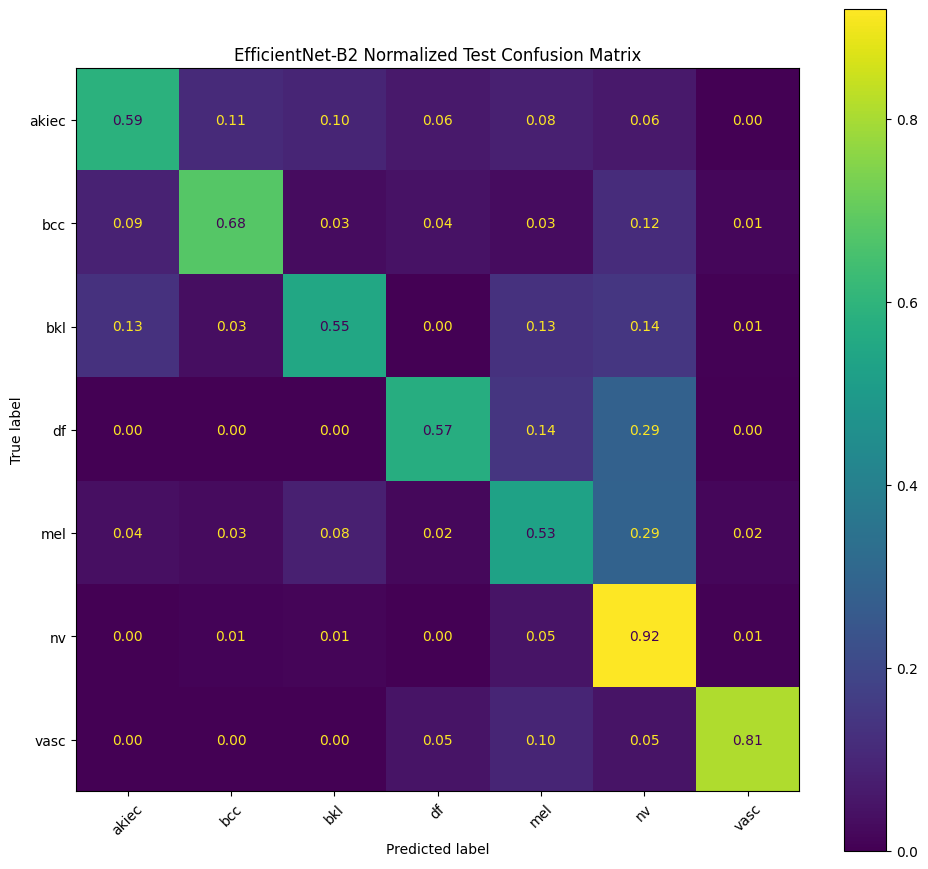

All plots were saved successfully.
Best epoch: 50
Best validation Macro F1: 0.6716
Loss curve: /kaggle/working/efficientnet_b2/loss_curve.png
Accuracy curve: /kaggle/working/efficientnet_b2/accuracy_curve.png
Macro F1 curve: /kaggle/working/efficientnet_b2/macro_f1_curve.png
Confusion matrix: /kaggle/working/efficientnet_b2/confusion_matrix.png
Normalized confusion matrix: /kaggle/working/efficientnet_b2/normalized_confusion_matrix.png


In [15]:
history_df = pd.read_csv(HISTORY_PATH)

if history_df.empty:
    raise ValueError("Training history is empty.")

best_epoch_index = history_df["val_f1"].idxmax()
best_epoch = int(history_df.loc[best_epoch_index, "epoch"])
best_validation_f1 = float(
    history_df.loc[best_epoch_index, "val_f1"]
)

phase_boundary = HEAD_EPOCHS + 0.5



fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

ax.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

ax.axvline(
    phase_boundary,
    linestyle="--",
    label="Full Fine-Tuning"
)

ax.set_title("EfficientNet-B2 Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

loss_plot_path = MODEL_DIR / "loss_curve.png"

fig.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)



fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Training Accuracy"
)

ax.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

ax.axvline(
    phase_boundary,
    linestyle="--",
    label="Full Fine-Tuning"
)

ax.set_title("EfficientNet-B2 Training and Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

accuracy_plot_path = MODEL_DIR / "accuracy_curve.png"

fig.savefig(
    accuracy_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)



fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    history_df["epoch"],
    history_df["train_f1"],
    label="Training Macro F1"
)

ax.plot(
    history_df["epoch"],
    history_df["val_f1"],
    label="Validation Macro F1"
)

ax.axvline(
    phase_boundary,
    linestyle="--",
    label="Full Fine-Tuning"
)

ax.axvline(
    best_epoch,
    linestyle=":",
    label=f"Best Epoch: {best_epoch}"
)

ax.scatter(
    best_epoch,
    best_validation_f1,
    zorder=5
)

ax.set_title("EfficientNet-B2 Training and Validation Macro F1")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1 Score")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

f1_plot_path = MODEL_DIR / "macro_f1_curve.png"

fig.savefig(
    f1_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)



fig, ax = plt.subplots(figsize=(10, 9))

ConfusionMatrixDisplay.from_predictions(
    test_targets,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
    display_labels=class_names,
    normalize=None,
    values_format="d",
    xticks_rotation=45,
    ax=ax
)

ax.set_title("EfficientNet-B2 Test Confusion Matrix")

fig.tight_layout()

confusion_matrix_path = MODEL_DIR / "confusion_matrix.png"

fig.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)



fig, ax = plt.subplots(figsize=(10, 9))

ConfusionMatrixDisplay.from_predictions(
    test_targets,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
    display_labels=class_names,
    normalize="true",
    values_format=".2f",
    xticks_rotation=45,
    ax=ax
)

ax.set_title(
    "EfficientNet-B2 Normalized Test Confusion Matrix"
)

fig.tight_layout()

normalized_confusion_matrix_path = (
    MODEL_DIR / "normalized_confusion_matrix.png"
)

fig.savefig(
    normalized_confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


print("All plots were saved successfully.")
print("Best epoch:", best_epoch)
print(
    f"Best validation Macro F1: "
    f"{best_validation_f1:.4f}"
)
print("Loss curve:", loss_plot_path)
print("Accuracy curve:", accuracy_plot_path)
print("Macro F1 curve:", f1_plot_path)
print("Confusion matrix:", confusion_matrix_path)
print(
    "Normalized confusion matrix:",
    normalized_confusion_matrix_path
)

Save Configuration and Create Final ZIP

In [16]:

class_mapping = {
    "class_to_idx": class_to_idx,
    "idx_to_class": {
        str(index): class_name
        for index, class_name in idx_to_class.items()
    }
}

with open(
    MODEL_DIR / "class_mapping.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        class_mapping,
        file,
        indent=4
    )



experiment_config = {
    "model_name": MODEL_NAME,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "maximum_epochs": TOTAL_EPOCHS,
    "head_training_epochs": HEAD_EPOCHS,
    "head_learning_rate": HEAD_LR,
    "backbone_learning_rate": BACKBONE_LR,
    "fine_tuning_head_learning_rate": FINETUNE_HEAD_LR,
    "weight_decay": WEIGHT_DECAY,
    "number_of_classes": NUM_CLASSES,
    "class_names": class_names,
    "training_samples": len(train_df),
    "validation_samples": len(validation_df),
    "test_samples": len(test_df),
    "device": str(DEVICE),
    "mixed_precision": USE_AMP,
    "best_model_selection_metric": "validation_macro_f1"
}

if "EARLY_STOPPING_PATIENCE" in globals():
    experiment_config["early_stopping"] = True
    experiment_config["early_stopping_patience"] = (
        EARLY_STOPPING_PATIENCE
    )
    experiment_config["early_stopping_min_delta"] = (
        EARLY_STOPPING_MIN_DELTA
    )
else:
    experiment_config["early_stopping"] = False

with open(
    MODEL_DIR / "experiment_config.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        experiment_config,
        file,
        indent=4
    )



summary_lines = [
    "EfficientNet-B2 HAM10000 Experiment",
    "=" * 45,
    f"Model: {MODEL_NAME}",
    f"Image size: {IMAGE_SIZE}",
    f"Number of classes: {NUM_CLASSES}",
    f"Training samples: {len(train_df)}",
    f"Validation samples: {len(validation_df)}",
    f"Test samples: {len(test_df)}",
    f"Maximum epochs: {TOTAL_EPOCHS}",
    f"Best validation Macro F1: {best_validation_f1:.4f}",
    f"Best epoch: {best_epoch}",
    f"Test accuracy: {test_accuracy:.4f}",
    f"Test Macro Precision: {macro_precision:.4f}",
    f"Test Macro Recall: {macro_recall:.4f}",
    f"Test Macro F1: {macro_f1:.4f}",
    f"Test Weighted F1: {weighted_f1:.4f}",
    (
        f"Test Macro ROC-AUC: {macro_roc_auc:.4f}"
        if not np.isnan(macro_roc_auc)
        else "Test Macro ROC-AUC: Not available"
    )
]

with open(
    MODEL_DIR / "experiment_summary.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write("\n".join(summary_lines))



zip_base_path = Path(
    "/kaggle/working/efficientnet_b2_results"
)

zip_path = Path(
    str(zip_base_path) + ".zip"
)

if zip_path.exists():
    zip_path.unlink()

created_archive = shutil.make_archive(
    base_name=str(zip_base_path),
    format="zip",
    root_dir=str(MODEL_DIR.parent),
    base_dir=MODEL_DIR.name
)

archive_size_mb = (
    Path(created_archive).stat().st_size
    / (1024 ** 2)
)

print("EfficientNet-B2 experiment package created successfully.")
print("ZIP path:", created_archive)
print(f"ZIP size: {archive_size_mb:.2f} MB")

print("\nFiles included:")
for saved_file in sorted(MODEL_DIR.rglob("*")):
    if saved_file.is_file():
        relative_path = saved_file.relative_to(
            MODEL_DIR
        )
        print(relative_path)

EfficientNet-B2 experiment package created successfully.
ZIP path: /kaggle/working/efficientnet_b2_results.zip
ZIP size: 110.35 MB

Files included:
accuracy_curve.png
class_mapping.json
classification_report.csv
classification_report.txt
confusion_matrix.png
efficientnet_b2_best_model.pth
efficientnet_b2_last_checkpoint.pth
experiment_config.json
experiment_summary.txt
loss_curve.png
macro_f1_curve.png
normalized_confusion_matrix.png
test_metrics.csv
test_metrics.json
test_predictions.csv
test_split.csv
train_split.csv
training_history.csv
validation_split.csv
